# Fase 3
- João Henrique Stolf Galeazzi
- Micael Conti
- Maria Júlia Testoni

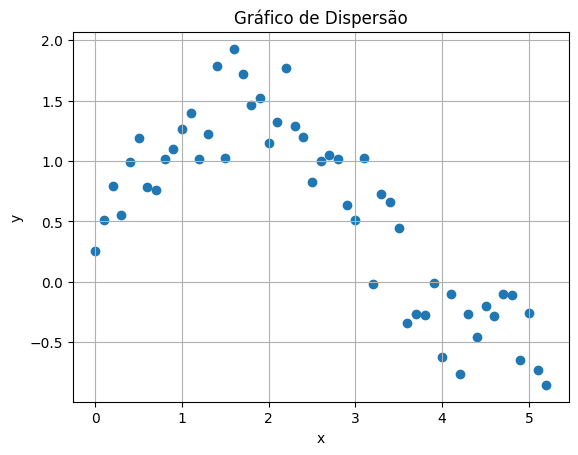

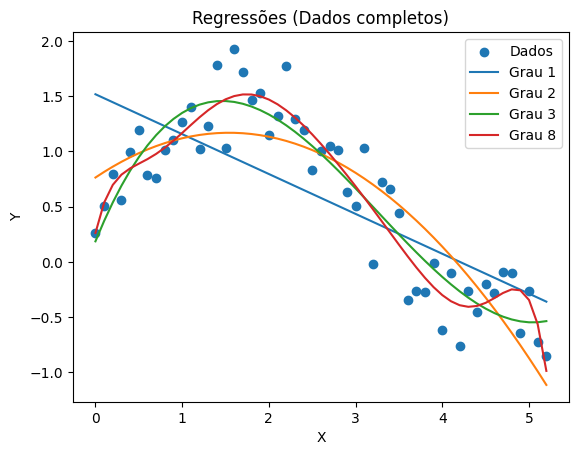


=== RESULTADOS (DADOS COMPLETOS) ===
Grau 1 | EQM: 0.265934 | R²: 0.5345
Grau 2 | EQM: 0.138526 | R²: 0.7575
Grau 3 | EQM: 0.078697 | R²: 0.8622
Grau 8 | EQM: 0.058709 | R²: 0.8972

Melhor modelo (EQM): Grau 8


/tmp/ipykernel_966/4193067815.py:26: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, grau)


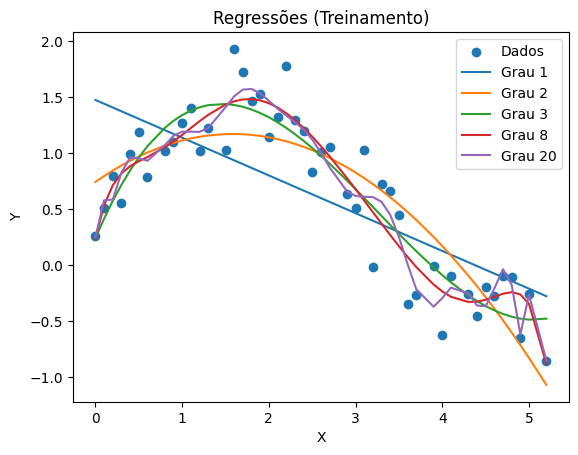


=== TESTE ===
Grau 1 | EQM: 0.368108 | R²: 0.5952
Grau 2 | EQM: 0.244458 | R²: 0.7312
Grau 3 | EQM: 0.128647 | R²: 0.8585
Grau 8 | EQM: 0.084200 | R²: 0.9074
Grau 20 | EQM: 1.524234 | R²: -0.6763

Melhor modelo no TESTE: Grau 8

=== R² TREINO ===
Grau 1 | R²: 0.5069
Grau 2 | R²: 0.7569
Grau 3 | R²: 0.8575
Grau 8 | R²: 0.8898
Grau 20 | R²: 0.9104

=== R² TESTE ===
Grau 1 | R²: 0.5952
Grau 2 | R²: 0.7312
Grau 3 | R²: 0.8585
Grau 8 | R²: 0.9074
Grau 20 | R²: -0.6763

Melhor modelo considerando TESTE: Grau 8

Análise do Grau 20:
- Espera-se baixo erro no treino (overfitting)
- Maior erro no teste
- Curva altamente oscilatória


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# =========================================================
# FUNÇÕES
# =========================================================

def calcular_polinomio(coef, x):
    return sum(coef[i] * (x ** i) for i in range(len(coef)))


def prever(coef, x):
    return np.array([calcular_polinomio(coef, xi) for xi in x])


def eqm(y_real, y_pred):
    return np.mean((y_real - y_pred) ** 2)


# Regressão usando polyfit (c, d, e, f)
def ajustar_modelos(x, y, graus):
    modelos = {}
    for grau in graus:
        coef = np.polyfit(x, y, grau)
        modelos[grau] = np.flip(coef)  # inversão conforme enunciado
    return modelos


# Avaliação (g, j, k)
def avaliar_modelos(modelos, x, y):
    resultados = {}

    for grau, coef in modelos.items():
        y_pred = prever(coef, x)

        resultados[grau] = {
            "EQM": eqm(y, y_pred),
            "R2": r2_score(y, y_pred)
        }

    return resultados


# Plot (c, d, e, f, m)
def plot_modelos(x, y, modelos, titulo):
    plt.figure()
    plt.scatter(x, y, label='Dados')

    x_ord = np.sort(x)

    for grau, coef in modelos.items():
        y_pred = prever(coef, x_ord)
        plt.plot(x_ord, y_pred, label=f'Grau {grau}')

    plt.title(titulo)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()


# =========================================================
# a) Leitura dos dados
# =========================================================
df = pd.read_csv('data_preg.csv', header=None)
df.columns = ['x', 'y']

x = df['x'].values
y = df['y'].values

# =========================================================
# b) Gráfico de dispersão
# =========================================================
plt.scatter(x, y)
plt.title('Gráfico de Dispersão')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

# =========================================================
# c, d, e, f) Regressões (graus 1, 2, 3 e 8)
# =========================================================
graus = [1, 2, 3, 8]

modelos = ajustar_modelos(x, y, graus)

plot_modelos(x, y, modelos, 'Regressões (Dados completos)')

# =========================================================
# g) EQM (dados completos)
# =========================================================
resultados = avaliar_modelos(modelos, x, y)

print("\n=== RESULTADOS (DADOS COMPLETOS) ===")
for grau, res in resultados.items():
    print(f"Grau {grau} | EQM: {res['EQM']:.6f} | R²: {res['R2']:.4f}")

melhor = min(resultados, key=lambda g: resultados[g]['EQM'])
print(f"\nMelhor modelo (EQM): Grau {melhor}")

# =========================================================
# h) Divisão treino/teste (90% / 10%)
# =========================================================
np.random.seed(42)

indices = np.random.permutation(len(x))
split = int(0.9 * len(x))

x_treino, x_teste = x[indices[:split]], x[indices[split:]]
y_treino, y_teste = y[indices[:split]], y[indices[split:]]

# =========================================================
# i) Regressões com dados de treinamento
# =========================================================
graus_todos = graus + [20]  # inclui grau 20 (m)

modelos_treino = ajustar_modelos(x_treino, y_treino, graus_todos)

plot_modelos(x_treino, y_treino, modelos_treino, 'Regressões (Treinamento)')

# =========================================================
# j) EQM nos dados de teste
# =========================================================
print("\n=== TESTE ===")
res_teste = avaliar_modelos(modelos_treino, x_teste, y_teste)

for grau, res in res_teste.items():
    print(f"Grau {grau} | EQM: {res['EQM']:.6f} | R²: {res['R2']:.4f}")

melhor_teste = min(res_teste, key=lambda g: res_teste[g]['EQM'])
print(f"\nMelhor modelo no TESTE: Grau {melhor_teste}")

# =========================================================
# k) R² (já calculado junto com EQM)
# =========================================================
print("\n=== R² TREINO ===")
res_treino = avaliar_modelos(modelos_treino, x_treino, y_treino)

for grau, res in res_treino.items():
    print(f"Grau {grau} | R²: {res['R2']:.4f}")

print("\n=== R² TESTE ===")
for grau, res in res_teste.items():
    print(f"Grau {grau} | R²: {res['R2']:.4f}")

# =========================================================
# l) Melhor modelo
# =========================================================
print(f"\nMelhor modelo considerando TESTE: Grau {melhor_teste}")

# =========================================================
# m) Grau 20 (já incluído acima)
# =========================================================
print("\nAnálise do Grau 20:")
print("- Espera-se baixo erro no treino (overfitting)")
print("- Maior erro no teste")
print("- Curva altamente oscilatória")